In [14]:
import os

satellite_root = "../../data/raw/satellite"

for root, dirs, files in os.walk(satellite_root):
    nc4_files = [f for f in files if f.endswith(".nc4")]
    
    if nc4_files:
        print("\nFolder:", root)
        print("Number of .nc4 files:", len(nc4_files))
        print("First few files:")
        
        for f in nc4_files[:5]:
            print("  ", f)


Folder: ../../data/raw/satellite\Hamoon
Number of .nc4 files: 20
First few files:
   merg_2023102006_4km-pixel.nc4
   merg_2023102012_4km-pixel.nc4
   merg_2023102018_4km-pixel.nc4
   merg_2023102100_4km-pixel.nc4
   merg_2023102118_4km-pixel.nc4

Folder: ../../data/raw/satellite\Mandous
Number of .nc4 files: 17
First few files:
   merg_2022120400_4km-pixel.nc4
   merg_2022120406_4km-pixel.nc4
   merg_2022120500_4km-pixel.nc4
   merg_2022120518_4km-pixel.nc4
   merg_2022120618_4km-pixel.nc4

Folder: ../../data/raw/satellite\Mocha
Number of .nc4 files: 25
First few files:
   merg_2023050800_4km-pixel.nc4
   merg_2023050818_4km-pixel.nc4
   merg_2023050906_4km-pixel.nc4
   merg_2023051006_4km-pixel.nc4
   merg_2023051018_4km-pixel.nc4

Folder: ../../data/raw/satellite\remal
Number of .nc4 files: 15
First few files:
   merg_2024052312_4km-pixel.nc4
   merg_2024052318_4km-pixel.nc4
   merg_2024052400_4km-pixel.nc4
   merg_2024052406_4km-pixel.nc4
   merg_2024052412_4km-pixel.nc4

Folder: 

In [13]:
import os
import matplotlib.pyplot as plt

output_dir = "../../data/processed/images/HAMOON"
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(
    output_dir,
    "HAMOON_20231020_0600.nc"
)

patch.to_netcdf(output_file)

print("Saved:")
print(output_file)

Saved:
../../data/processed/images/HAMOON\HAMOON_20231020_0600.nc


In [12]:
import os
import matplotlib.pyplot as plt

# Create output folder
output_dir = "../../data/processed/images/HAMOON"
os.makedirs(output_dir, exist_ok=True)

# Save the patch as NetCDF
output_file = os.path.join(
    output_dir,
    "HAMOON_20231020_0600.nc"
)

patch.to_netcdf(output_file)

print("Saved:")
print(output_file)

Saved:
../../data/processed/images/HAMOON\HAMOON_20231020_0600.nc


In [11]:
print("Tb minimum:", float(ds["Tb"].min()))
print("Tb maximum:", float(ds["Tb"].max()))
print("Tb mean:", float(ds["Tb"].mean()))

print("\nTb information:")
print(ds["Tb"])

Tb minimum: 182.0
Tb maximum: 329.0
Tb mean: 278.7839660644531

Tb information:
<xarray.DataArray 'Tb' (time: 2, lat: 3298, lon: 9896)> Size: 261MB
array([[[ nan,  nan, ...,  nan,  nan],
        [ nan,  nan, ...,  nan,  nan],
        ...,
        [271., 271., ..., 271., 271.],
        [271., 271., ..., 271., 271.]],

       [[ nan,  nan, ...,  nan,  nan],
        [ nan,  nan, ...,  nan,  nan],
        ...,
        [271., 271., ..., 271., 271.],
        [271., 271., ..., 271., 271.]]], shape=(2, 3298, 9896), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 16B 2023-10-20T06:00:00 2023-10-20T06:30:0...
  * lat      (lat) float32 13kB -59.98 -59.95 -59.91 ... 59.91 59.95 59.98
  * lon      (lon) float32 40kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Attributes:
    units:          K
    standard_name:  brightness_temperature


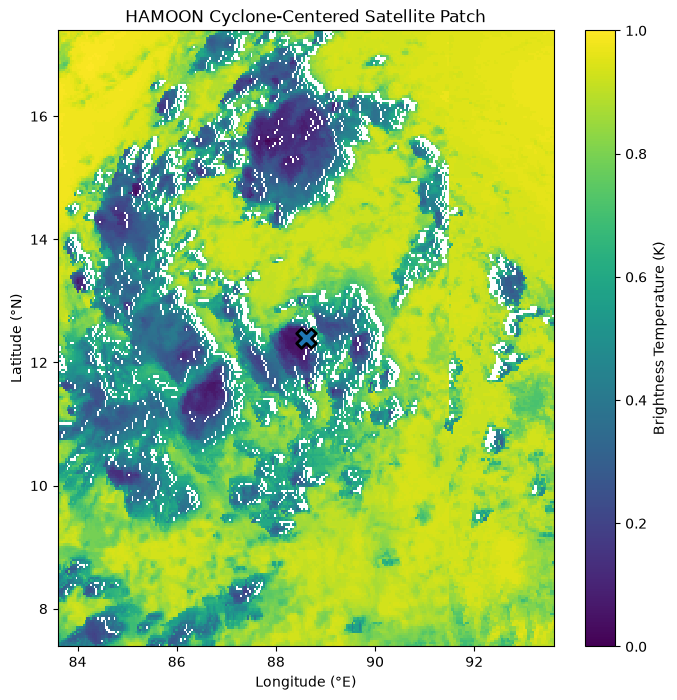

In [10]:
plt.figure(figsize=(8, 8))

plt.pcolormesh(
    patch["lon"],
    patch["lat"],
    patch,
    shading="auto"
)

plt.scatter(
    cyclone_lon,
    cyclone_lat,
    marker="X",
    s=200,
    edgecolors="black",
    linewidths=2
)

plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title("HAMOON Cyclone-Centered Satellite Patch")

plt.colorbar(label="Brightness Temperature (K)")

plt.show()

In [9]:
# Cyclone center
cyclone_lat = 12.4
cyclone_lon = 88.6

# Size of the area we want around the cyclone
lat_range = 5
lon_range = 5

# Crop the satellite data
patch = ds["Tb"].isel(time=0).sel(
    lat=slice(
        cyclone_lat - lat_range,
        cyclone_lat + lat_range
    ),
    lon=slice(
        cyclone_lon - lon_range,
        cyclone_lon + lon_range
    )
)

print(patch)

<xarray.DataArray 'Tb' (lat: 275, lon: 275)> Size: 302kB
array([[257., 248., 241., ..., 290., 290., 288.],
       [271., 249., 242., ..., 289., 289., 286.],
       [268., 263., 251., ..., 289., 286., 286.],
       ...,
       [288., 291., 293., ..., 296., 297., 297.],
       [291., 292., 292., ..., 296., 297., 297.],
       [291., 292., 294., ..., 297., 297., 296.]],
      shape=(275, 275), dtype=float32)
Coordinates:
  * lat      (lat) float32 1kB 7.404 7.441 7.477 7.514 ... 17.3 17.34 17.37
  * lon      (lon) float32 1kB 83.62 83.65 83.69 83.72 ... 93.51 93.55 93.58
    time     datetime64[ns] 8B 2023-10-20T06:00:00
Attributes:
    units:          K
    standard_name:  brightness_temperature


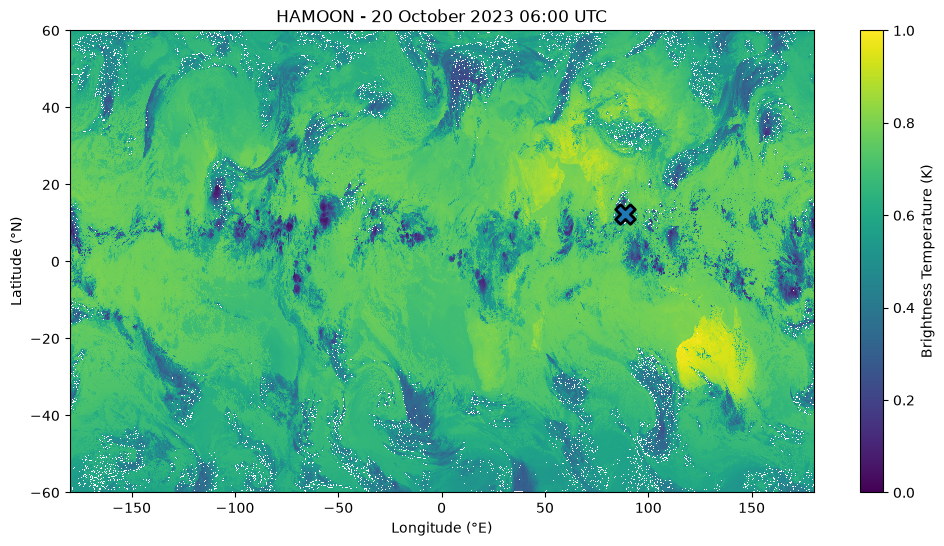

In [8]:
# Hamoon's position from IBTrACS
cyclone_lat = 12.4
cyclone_lon = 88.6

# Draw the satellite image
plt.figure(figsize=(12, 6))

plt.pcolormesh(
    ds["lon"],
    ds["lat"],
    ds["Tb"].isel(time=0),
    shading="auto"
)

# Put an X at Hamoon's location
plt.scatter(
    cyclone_lon,
    cyclone_lat,
    marker="X",
    s=200,
    edgecolors="black",
    linewidths=2
)

plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title("HAMOON - 20 October 2023 06:00 UTC")

plt.colorbar(label="Brightness Temperature (K)")

plt.show()

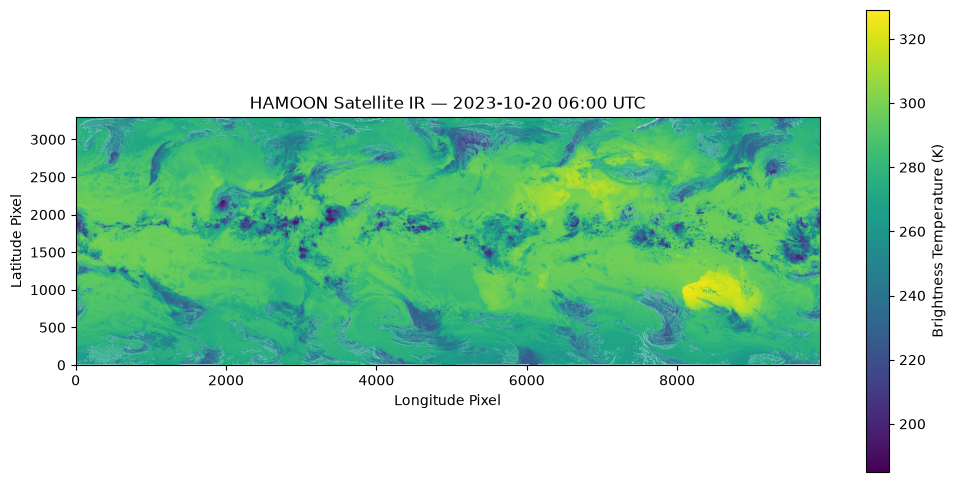

In [7]:
plt.figure(figsize=(12, 6))

plt.imshow(
    ds["Tb"].isel(time=0),
    origin="lower"
)

plt.title("HAMOON Satellite IR — 2023-10-20 06:00 UTC")
plt.xlabel("Longitude Pixel")
plt.ylabel("Latitude Pixel")

plt.colorbar(label="Brightness Temperature (K)")

plt.show()

In [6]:
data = ds["Tb"]

print("Shape:", data.shape)
print("Minimum:", np.nanmin(data.values))
print("Maximum:", np.nanmax(data.values))
print("Mean:", np.nanmean(data.values))
print("Missing values:", np.isnan(data.values).sum())

Shape: (2, 3298, 9896)
Minimum: 182.0
Maximum: 329.0
Mean: 278.78397
Missing values: 1285863


In [3]:
file = "../../data/raw/satellite/Hamoon/merg_2023102006_4km-pixel.nc4"

ds = xr.open_dataset(file)

print(ds)

<xarray.Dataset> Size: 261MB
Dimensions:  (time: 2, lat: 3298, lon: 9896)
Coordinates:
  * time     (time) datetime64[ns] 16B 2023-10-20T06:00:00 2023-10-20T06:30:0...
  * lat      (lat) float32 13kB -59.98 -59.95 -59.91 ... 59.91 59.95 59.98
  * lon      (lon) float32 40kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    Tb       (time, lat, lon) float32 261MB ...
Attributes:
    BeginDate:       2023-10-20
    BeginTime:       06:00:00.000Z
    EndDate:         2023-10-20
    EndTime:         06:59:59.999Z
    FileHeader:      StartGranuleDateTime=2023-10-20T06:00:00.000Z;\nStopGran...
    InputPointer:    merg_2023102006_4km-pixel
    title:           NCEP/CPC 4km Global (60N - 60S) IR Dataset
    ProductionTime:  2025-08-22T17:04:07.704Z
    DOI:             10.5067/P4HZB9N27EKU


In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

print("Everything is ready!")

Everything is ready!
